# Detección de esquinas
# Saul Canche




Plan:
Se usara el metodo threshold para obtener el threshold optimo para usar en Canny, una vez optenido los contornos con canny lo que sigue es usar la transformada de hough para encontrar la linea, se usara el metodo houghLinesP para obtener los 2 puntos que definen a las lineas. Despues buscaremos las interesecciones de estas lineas.

### importe y lectura de la image

In [151]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
I = cv2.imread('/content/Reticula_0.png', cv2.IMREAD_GRAYSCALE)

## Bordes con Canny
En lugar de tantear los valores de el threshold para esta imagen, se optó umbrales dinámicos obtenidos por medio del siguiente metodo: Otsu (cv2.THRESH_OTSU), el cual analiza el histograma de la imagen y calcula de forma autónoma el valor óptimo que separa las clases de píxeles minimizando la varianza intra-clase,
luego el umbral inferior se definió como el 50% de este valor superior

In [152]:
high_thresh, _ = cv2.threshold(I, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
low_thresh = 0.5 * high_thresh
edges = cv2.Canny(I, low_thresh, high_thresh)

vemos que efectivamente canny encontro los bordes sin problema

Original Image:


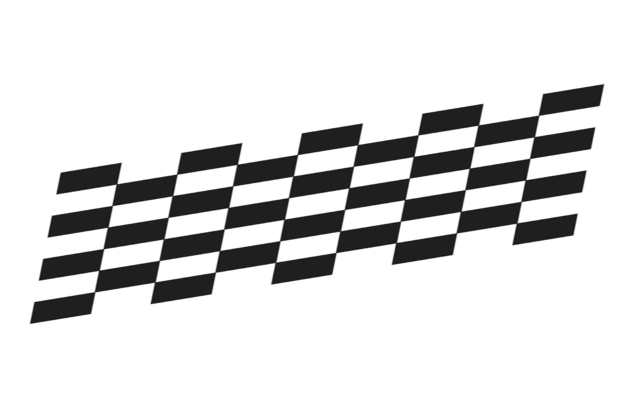

Canny Edges:


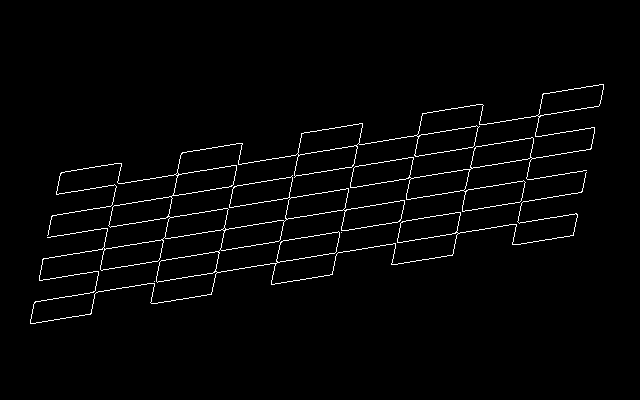

In [153]:
print('Original Image:')
cv2_imshow(I)
print('Canny Edges:')
cv2_imshow(edges)

## Extracción de lineas
Para la extracción de las líneas, se uso (cv2.HoughLinesP). Se eligió esta variante en lugar de la transformada estándar porque devuelve los puntos extremos de los segmentos finitos ($x_1, y_1, x_2, y_2$) en lugar de líneas infinitas. Los parámetros de resolución del espacio de Hough se configuraron a $1$ píxel para la distancia ($\rho$) y $\pi/180$ radianes (1 grado) para el ángulo ($\theta$). Para asegurar la robustez, se estableció un umbral de votación (threshold) de 30. Además, se aplicaron restricciones geométricas importantes: se descartaron ruidos filtrando cualquier segmento menor a 30 píxeles (minLineLength=30) y se unieron segmentos colineales fragmentados que tuvieran una separación de 10 píxeles o menos (maxLineGap=10). El resultado de esta función es un arreglo multidimensional con shape $(N, 1, 4)$, que nos servira para encontrar las interesecciones

In [154]:
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30, minLineLength=30, maxLineGap=10)
lines.shape

(42, 1, 4)

Para encontrar los cruces, la función intersect_with_tolerance resuelve el sistema usando las ecuaciones paramétricas de los segmentos. El cálculo de den es el determinante luego si da 0, las líneas son paralelas y se descartan.El detalle importante aquí es el uso de la tolerancia (tol). Como HoughLinesP a veces devuelve segmentos que se cortan un par de píxeles antes de tocar la otra línea, expandir ligeramente los límites de los parámetros t y u (que estrictamente deberían ir de 0 a 1) permite detectar esos cruces "imperfectos" y no perder esquinas.

Para procesar todas las líneas, iteramos comparando todos los pares posibles.
Si se detecta una intersección, se calcula la distancia euclidiana contra los puntos ya encontrados para evitar guardar puntos duplicados o muy juntos en una misma esquina.Sé que esta implementación es pura fuerza bruta ($O(N^3)$ en el peor de los casos y hay mucho margen para optimizar pere, como el número de líneas detectadas ($N$) en esta imagen es muy bajo, la fuerza bruta corre en milisegundos y es más que suficiente para cumplir con el objetivo de la tarea sin sobrecomplicar el código.

In [155]:
def intersect_with_tolerance(line1, line2, tol=0.1):
    x1, y1, x2, y2 = line1[0]
    x3, y3, x4, y4 = line2[0]
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if den == 0: return None
    t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / den
    u = -((x1 - x2) * (y1 - y3) - (y1 - y2) * (x1 - x3)) / den
    if -tol <= t <= 1 + tol and -tol <= u <= 1 + tol:
        ix = int(x1 + t * (x2 - x1))
        iy = int(y1 + t * (y2 - y1))
        return (ix, iy)
    return None
intersection_points = []
min_distance = 15
if lines is not None:
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            p = intersect_with_tolerance(lines[i], lines[j], tol=0.15)
            if p is not None:
                is_unique = True
                for existing_p in intersection_points:
                    dist = ((p[0] - existing_p[0])**2 + (p[1] - existing_p[1])**2)**0.5
                    if dist < min_distance:
                        is_unique = False
                        break
                if is_unique:
                    intersection_points.append(p)

## Resultados

Para ver los puntos en la imagen simplemente pintamos los puntos de rojo en la imagen original. Como la imagen original I está en escala de grises (un solo canal), primero hay que convertirla a 3 canales con cv2.cvtColor.
Después, iteramos sobre nuestra lista ya filtrada de intersection_points y usamos cv2.circle para marcar cada cruce.

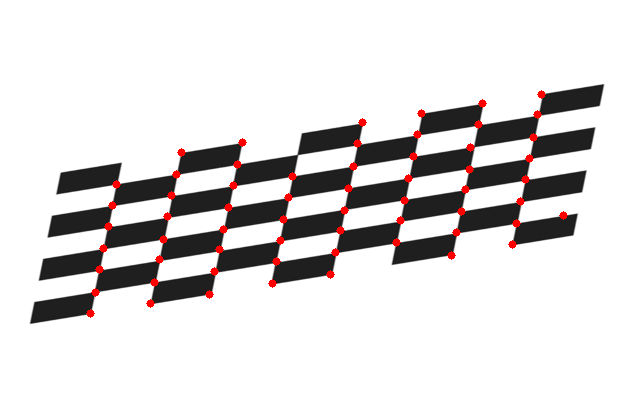

In [156]:
I_with_intersection = cv2.cvtColor(I, cv2.COLOR_GRAY2BGR)
for p in intersection_points:
    cv2.circle(I_with_intersection, p, 4, (0, 0, 255), -1)
cv2_imshow(I_with_intersection)

In [157]:
pts_np = np.array(intersection_points)
np.savetxt('intersectionsR0.csv', pts_np, delimiter=',', header='x,y', comments='', fmt='%d')

In [158]:
cv2.imwrite('intersectionsR0.png', I_with_intersection)

True